<a href="https://colab.research.google.com/github/Phalguni-dhabale/PR-LAB/blob/main/PR_PRACTICAL_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import pandas as pd
import numpy as np
import zipfile

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
zip_file = zipfile.ZipFile('sms+spam+collection.zip')

zip_file.extractall()

zip_file.close()

In [12]:
df = pd.read_csv(
    "SMSSpamCollection",
    sep="\t",
    names=["Label","Message"]
)

df.head()

,Label,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Label    5572 non-null   object
 1   Message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [14]:
df.shape

(5572, 2)

In [15]:
df['Label'].value_counts()

,count
Label,
ham,4825
spam,747


In [16]:
df.isnull().sum()

,0
Label,0
Message,0


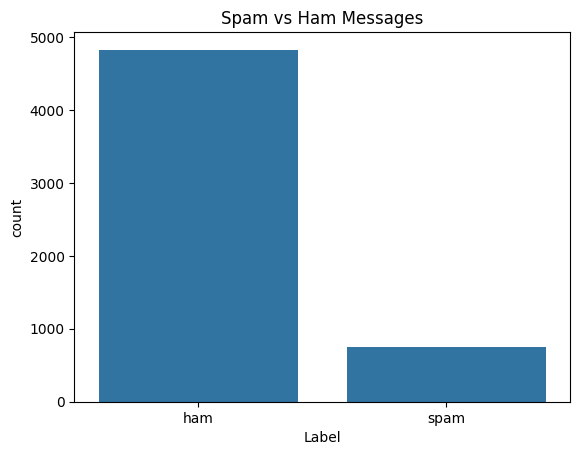

In [17]:
sns.countplot(x='Label', data=df)

plt.title("Spam vs Ham Messages")

plt.show()

In [18]:
df['Label'] = df['Label'].map({
    'ham':0,
    'spam':1
})

df.head()

,Label,Message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [19]:
vectorizer = CountVectorizer(stop_words='english')

X = vectorizer.fit_transform(df['Message'])

y = df['Label']

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [21]:
model = MultinomialNB()

model.fit(X_train, y_train)

MultinomialNB()

In [22]:
y_pred = model.predict(X_test)

In [23]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9829596412556054


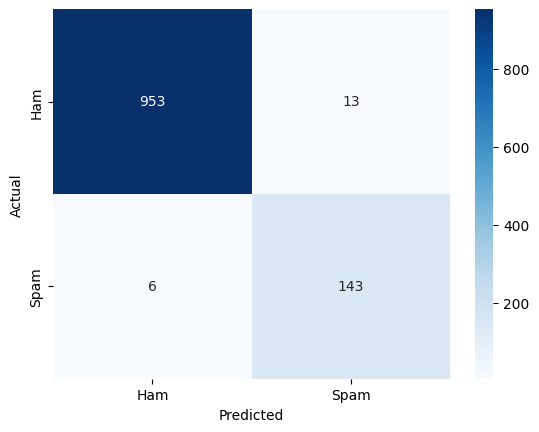

In [24]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Ham','Spam'],
    yticklabels=['Ham','Spam']
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [25]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       966
           1       0.92      0.96      0.94       149

    accuracy                           0.98      1115
   macro avg       0.96      0.97      0.96      1115
weighted avg       0.98      0.98      0.98      1115



In [26]:
feature_names = vectorizer.get_feature_names_out()

spam_words = model.feature_log_prob_[1]

top_spam = np.argsort(spam_words)[-20:]

for i in top_spam:
    print(feature_names[i])

50
nokia
150p
won
win
uk
just
new
send
cash
prize
www
claim
reply
stop
mobile
text
ur
txt
free


In [27]:
message = ["Congratulations! You have won a free iPhone. Claim your prize now."]

message_vector = vectorizer.transform(message)

prediction = model.predict(message_vector)

if prediction[0] == 1:
    print("Spam")
else:
    print("Ham")

Spam
